# Unit 3: EEG 信号处理与滤波技术

## 学习目标
- 理解 EEG 信号中常见噪声来源及其特征
- 掌握 Butterworth 滤波器设计与应用
- 实现带通滤波、陷波滤波与基线校正
- 学会使用 scipy.signal 进行信号预处理
- 能够对滤波前后的信号进行对比分析

## 核心概念

### EEG 信号频率范围
人脑脑电信号主要集中在 **0.5-100 Hz** 范围内，分为以下几个典型频段：

| 频段 | 频率范围 | 关联状态 |
|------|---------|---------|
| Delta | 0.5-4 Hz | 深睡、无意识 |
| Theta | 4-8 Hz | 冥想、困倦 |
| Alpha | 8-13 Hz | 放松闭眼、静息 |
| Beta | 13-30 Hz | 警觉、认知处理 |
| Gamma | 30-100 Hz | 高级认知、绑定处理 |

### 常见噪声来源
- **工频干扰**：50 Hz（中国/欧洲）或 60 Hz（美国/日本），来自电源线
- **肌电伪影（EMG）**：20-200 Hz，来自面部或颈部肌肉活动
- **眼电伪影（EOG）**：<4 Hz，来自眼球运动和眨眼
- **直流偏移**：电极-皮肤接触导致的低频漂移
- **运动伪影**：来自身体运动，影响加速度计可检测

### 滤波器类型
- **低通滤波器（LPF）**：允许低频信号通过，衰减高频信号
- **高通滤波器（HPF）**：允许高频信号通过，衰减低频信号
- **带通滤波器（BPF）**：仅允许特定频率范围内的信号通过
- **陷波滤波器（Notch）**：衰减特定窄频带（如 50/60 Hz 工频）

### Butterworth 滤波器
Butterworth 滤波器具有**最大平坦通带**特性，无纹波，在 EEG 处理中最为常用。
- **阶数（order）**：决定过渡带陡峭程度，阶数越高衰减越快
- **截止频率（cutoff）**：信号衰减 -3dB 处的频率

## 1. 环境准备

In [13]:
import numpy as np
import pandas as pd
from scipy import signal
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from typing import Dict, Optional, Tuple

print("Modules imported successfully.")

# 设置绘图样式
plt.style.use('default')  # 其他样式：ggplot、seaborn-v0_8、classic
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
# rcParams 是全局默认设置，设置一次后后面的图都会受影响。

Modules imported successfully.


## 2. 生成模拟 EEG 信号（含噪声）

为演示滤波效果，我们首先生成包含真实特征和噪声的模拟 EEG 信号。

In [14]:
def generate_simulated_eeg(
    duration: float = 10.0,
    sfreq: float = 250.0,
    include_noise: bool = True
) -> Tuple[np.ndarray, np.ndarray]:
    """
    生成包含多种脑波节律和噪声的模拟 EEG 信号
    
    Args:
        duration: 信号持续时间（秒）
        sfreq: 采样频率（Hz）
        include_noise: 是否添加噪声成分
    
    Returns:
        times: 时间轴数组
        eeg_signal: 模拟 EEG 信号
    """
    np.random.seed(123)
    n_samples = int(duration * sfreq)
    times = np.arange(n_samples) / sfreq
    # 两个相邻采样点之间的时间间隔是：1/sfreq
    
    # 初始化信号
    eeg = np.zeros(n_samples)
    
    # Delta 波 (1-4 Hz): 大幅低频振荡
    eeg += 30 * np.sin(2 * np.pi * 2 * times)
    
    # Theta 波 (4-8 Hz)
    eeg += 15 * np.sin(2 * np.pi * 6 * times)
    
    # Alpha 波 (8-13 Hz): 闭眼放松状态，通常在枕叶显著
    eeg += 25 * np.sin(2 * np.pi * 10 * times)
    
    # Beta 波 (13-30 Hz): 低幅高频
    eeg += 8 * np.sin(2 * np.pi * 20 * times)
    
    # Gamma 波 (30-50 Hz): 非常低幅
    eeg += 3 * np.sin(2 * np.pi * 40 * times)
    
    if include_noise:
        # 直流偏移（缓慢漂移）
        # 第一步 生成 n_samples 个服从标准正态分布的随机数。
        # 第二步 对随机数进行累计求和，得到一个时间序列。
        # 第三步 对时间序列进行缩放，得到一个慢速变化移的信号。。
        # drift 每一步随机往上或往下走一点，当前位置由前面所有步数累积决定。
        drift = np.cumsum(np.random.randn(n_samples)) * 0.1
        eeg += drift
        
        # 50 Hz 工频干扰（中国标准）
        eeg += 15 * np.sin(2 * np.pi * 50 * times)
        
        # 100 Hz 谐波
        eeg += 5 * np.sin(2 * np.pi * 100 * times)
        
        # 高斯白噪声（模拟电极热噪声）
        eeg += np.random.randn(n_samples) * 3
        
        # 模拟眨眼伪影（随机出现的大幅低频脉冲）
        # 随机生成 5 个眨眼发生的时间点
        # 不在最开始和最后一秒生成眨眼，避免眨眼波形被截断。
        blink_times = np.random.uniform(1, duration - 1, 5)
        for bt in blink_times:
            blink_idx = int(bt * sfreq)
            blink_duration = int(0.2 * sfreq)  # 200ms=50个采样点
            # blink = 100 * 衰减包络 * 正弦波
            blink = 100 * np.exp(-np.linspace(0, 5, blink_duration)) * np.sin(np.linspace(0, 4*np.pi, blink_duration))
            if blink_idx + blink_duration <= n_samples:
                eeg[blink_idx:blink_idx + blink_duration] += blink
    
    return times, eeg

# 生成含噪声的信号
times, eeg_noisy = generate_simulated_eeg(duration=10, sfreq=250, include_noise=True)
# 生成纯净信号（用于对比）
_, eeg_clean = generate_simulated_eeg(duration=10, sfreq=250, include_noise=False)

print(f"Signal duration: {len(times)/250:.1f} seconds")
print(f"Number of samples: {len(times)}")
print(f"Sampling rate: 250 Hz")
print(f"eeg_noisy shape: {eeg_noisy.shape}")

Signal duration: 10.0 seconds
Number of samples: 2500
Sampling rate: 250 Hz
eeg_noisy shape: (2500,)


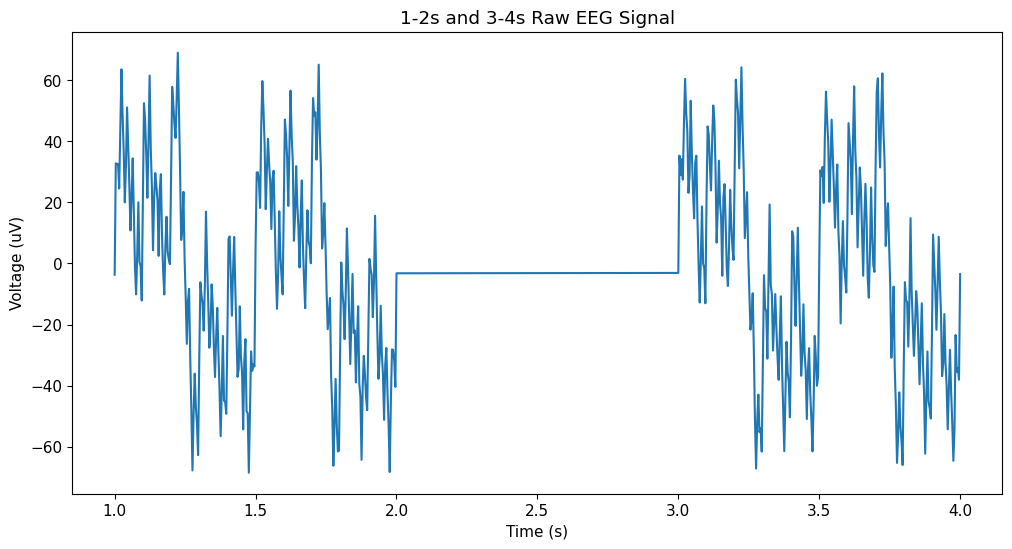

In [15]:
mask = ((times >= 1) & (times <= 2)) | ((times >= 3) & (times <= 4))

plt.plot(times[mask], eeg_noisy[mask])
plt.title("1-2s and 3-4s Raw EEG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (uV)")
plt.show()


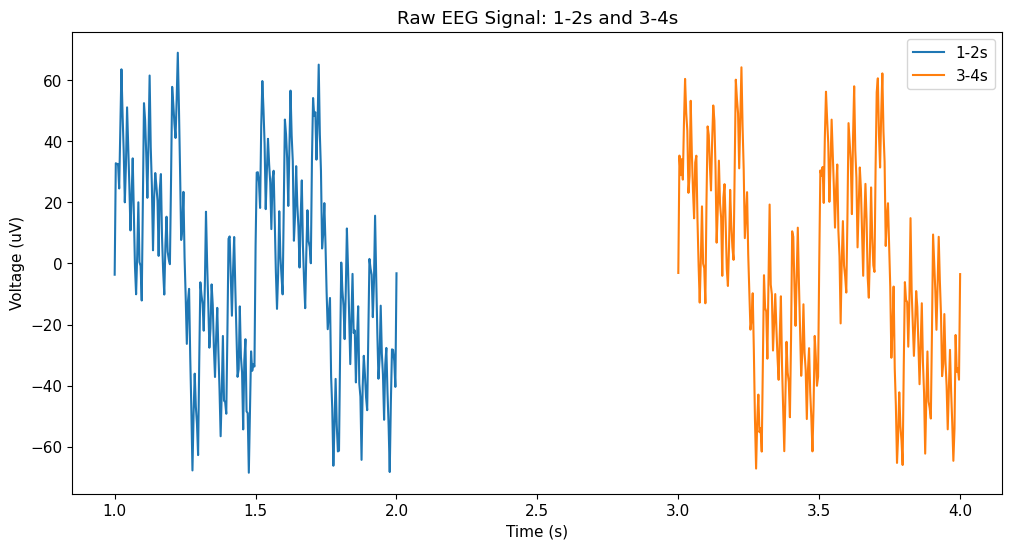

In [16]:
mask1 = (times >= 1) & (times <= 2)
mask2 = (times >= 3) & (times <= 4)

plt.plot(times[mask1], eeg_noisy[mask1], label="1-2s")
plt.plot(times[mask2], eeg_noisy[mask2], label="3-4s")

plt.title("Raw EEG Signal: 1-2s and 3-4s")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (uV)")
plt.legend()
plt.show()

## 3. 滤波器设计与实现

### 3.1 Butterworth 带通滤波器

In [17]:
def design_bandpass_filter(
    lowcut: float,
    highcut: float,
    fs: float,
    order: int = 4
) -> Tuple[np.ndarray, np.ndarray]:
    """
    设计 Butterworth 带通滤波器
    
    Args:
        lowcut: 低频截止频率（Hz）
        highcut: 高频截止频率（Hz）
        fs: 采样频率（Hz）
        order: 滤波器阶数（越高过渡带越陡，但可能引入相位失真）
    
    Returns:
        b, a: 滤波器系数（分子和分母）
    
    Note:
        奈奎斯特频率 = fs / 2，所有截止频率必须归一化到此范围
        例如 fs=250Hz 时，最高可处理 125Hz 的信号
    """
    nyquist = fs / 2.0  # 奈奎斯特频率
    low = lowcut / nyquist  # 归一化低频
    high = highcut / nyquist  # 归一化高频
    # 0   表示 0 Hz
    # 1   表示 奈奎斯特频率 fs/2
    
    # order阶数越高，滤波器越“陡峭”
    # sos (second-order sections) 格式比 b,a 格式数值稳定性更好
    # 把一个高阶滤波器拆成多个二阶小滤波器串联
    sos = signal.butter(order, [low, high], btype='band', output='sos')
    # 使用时配合 filtered = signal.sosfiltfilt(sos, data) 应用滤波器，确保零相位滤波。
    return sos


def apply_filter(sos: np.ndarray, data: np.ndarray, forward_backward: bool = True) -> np.ndarray:
    """
    应用滤波器到信号
    
    Args:
        sos: 滤波器系数（二阶节格式）
        data: 输入信号
        forward_backward: 是否使用零相位滤波（filtfilt）
            True: 前向-后向滤波，消除相位延迟，适用于离线分析
            False: 单向滤波，保留相位信息，适用于实时处理
    
    Returns:
        滤波后的信号
    """
    if forward_backward:
        # sosfiltfilt: 零相位数字滤波器，信号正向和反向各滤波一次
        # 优点：无相位延迟；缺点：需要缓存，不适用于实时
        return signal.sosfiltfilt(sos, data)
    else:
        # sosfilt: 单向滤波
        return signal.sosfilt(sos, data)


# 设计 EEG 带通滤波器 (0.5-45 Hz)
# 这个范围涵盖了 Delta 到 Gamma 的主要脑电活动
eeg_bandpass_sos = design_bandpass_filter(lowcut=0.5, highcut=45, fs=250, order=4)
print("EEG bandpass filter (0.5-45 Hz) designed.")

EEG bandpass filter (0.5-45 Hz) designed.


### 3.2 陷波滤波器（Notch Filter）

专门用于消除 50/60 Hz 工频干扰。

In [18]:
def design_notch_filter(
    freq: float,
    fs: float,
    quality_factor: float = 30.0
) -> Tuple[np.ndarray, np.ndarray]:
    """
    设计 IIR 陷波滤波器
    
    Args:
        freq: 需要消除的频率（Hz），中国为 50 Hz
        fs: 采样频率（Hz）
        quality_factor (Q): 品质因数，决定陷波带宽
            Q 越高，陷波越窄，只消除目标频率
            带宽 = freq / Q
            例如: 50 Hz / 30 = 1.67 Hz 带宽
    
    Returns:
        b, a: 滤波器系数
    """
    # scipy.signal.iirnotch 直接返回 b, a 系数
    # Q 越高，陷波越窄，只消除目标频率
    b, a = signal.iirnotch(freq, quality_factor, fs)
    return b, a


# 设计 50 Hz 陷波滤波器
# Q 越高，陷波越窄，只消除目标频率
notch_b, notch_a = design_notch_filter(freq=50, fs=250, quality_factor=30)
print("50 Hz notch filter designed.")
print(f"Bandwidth: {50/30:.2f} Hz")

50 Hz notch filter designed.
Bandwidth: 1.67 Hz


## 4. 滤波器频率响应可视化

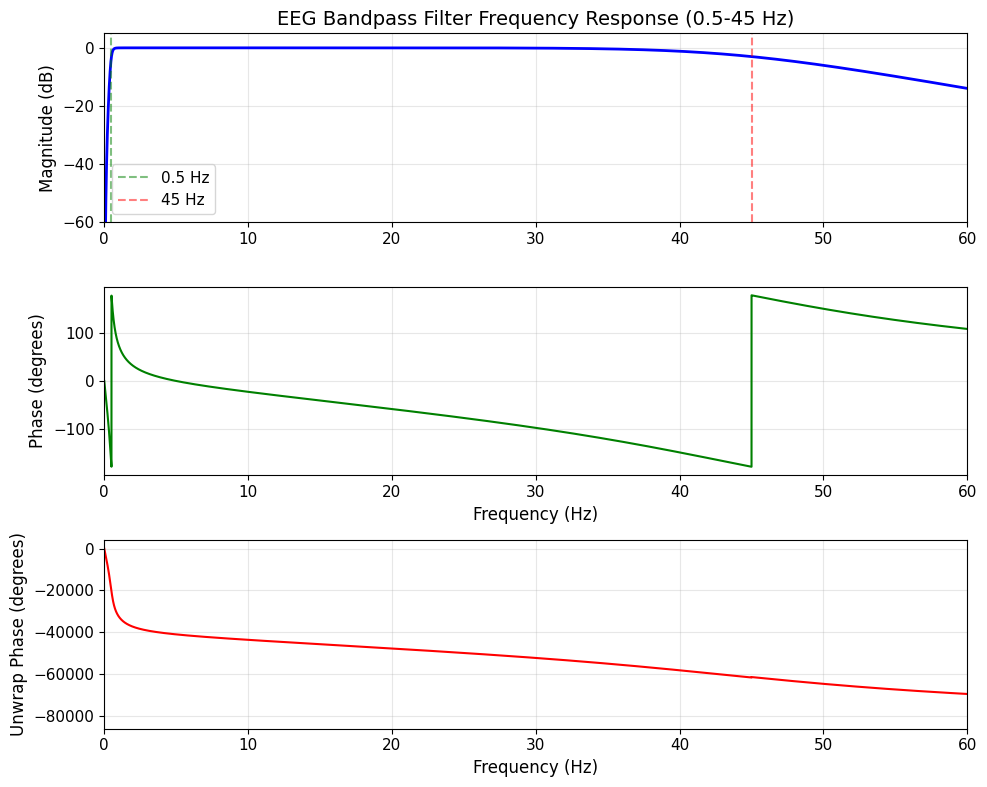

In [19]:
# 可视化带通滤波器的频率响应
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))

# freqz: 计算数字滤波器的频率响应
# 用来分析：这个滤波器对不同频率的信号会保留多少、削弱多少
# 它会在 0 Hz 到 fs/2 之间取 1024 个点，计算每个频率点的滤波器响应
# w 是频率数组
# h 是滤波器在每个频率点上的 复数响应,包含：
# 幅度响应：这个频率被放大/保留/削弱多少
# 相位响应：这个频率的相位被移动多少
# 通常我们最关心的是幅度响应，所以会写：np.abs(h)
w, h = signal.sosfreqz(eeg_bandpass_sos, worN=65536, fs=250)

# 1e-10 是为了避免 log10(0)负无穷大
ax1.plot(w, 20 * np.log10(np.maximum(abs(h), 1e-10)), 'b', linewidth=2)
ax1.set_title('EEG Bandpass Filter Frequency Response (0.5-45 Hz)', fontsize=14)
ax1.set_ylabel('Magnitude (dB)', fontsize=12)
ax1.set_xlim(0, 60)
ax1.set_ylim(-60, 5)
ax1.grid(True, alpha=0.3)
ax1.axvline(x=0.5, color='g', linestyle='--', alpha=0.5, label='0.5 Hz')
ax1.axvline(x=45, color='r', linestyle='--', alpha=0.5, label='45 Hz')
ax1.legend()

# 相位响应
phase = np.angle(h) * 180 / np.pi
ax2.plot(w, phase, 'g', linewidth=1.5)
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Phase (degrees)', fontsize=12)
ax2.set_xlim(0, 60)
ax2.grid(True, alpha=0.3)

phase2 = np.unwrap(phase) * 360 / np.pi
ax3.plot(w, phase2, 'r', linewidth=1.5)
ax3.set_xlabel('Frequency (Hz)', fontsize=12)
ax3.set_ylabel('Unwrap Phase (degrees)', fontsize=12)
ax3.set_xlim(0, 60)
ax3.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

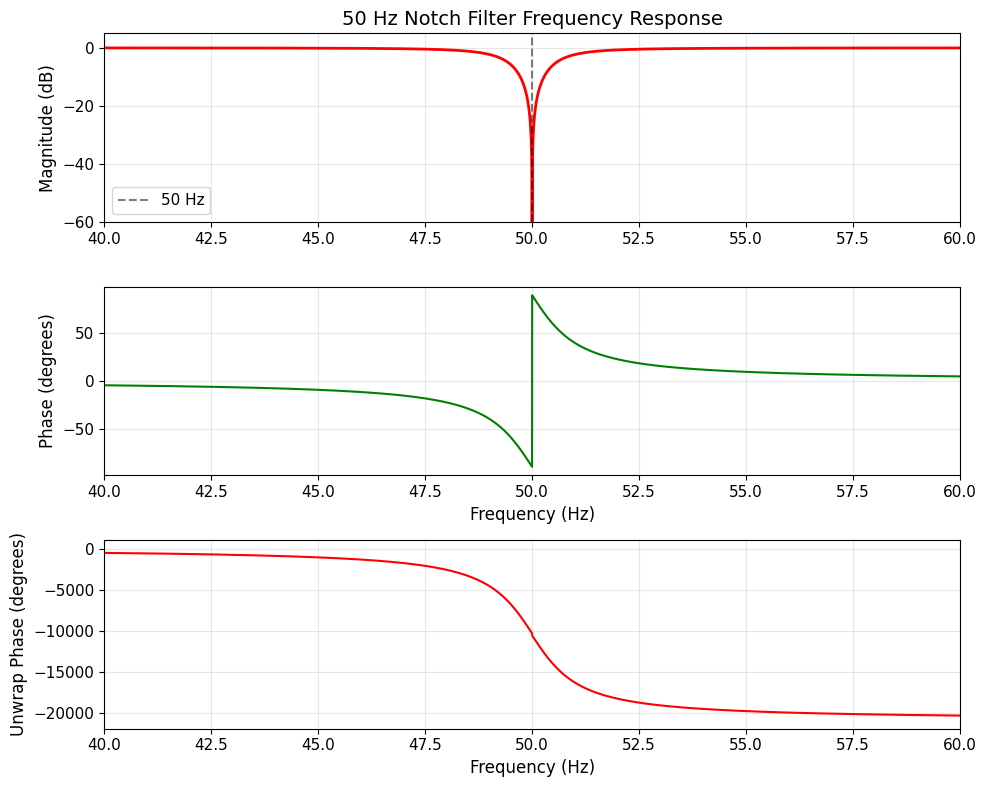

In [20]:
# 可视化陷波滤波器的频率响应
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))  

w_notch, h_notch = signal.freqz(notch_b, notch_a, worN=65536, fs=250)

ax1.plot(w_notch, 20 * np.log10(np.maximum(abs(h_notch), 1e-10)), 'r', linewidth=2)
ax1.set_title('50 Hz Notch Filter Frequency Response', fontsize=14)
ax1.set_ylabel('Magnitude (dB)', fontsize=12)
ax1.set_xlim(40, 60)
ax1.set_ylim(-60, 5)
ax1.grid(True, alpha=0.3)
ax1.axvline(x=50, color='k', linestyle='--', alpha=0.5, label='50 Hz')
ax1.legend()

phase = np.angle(h_notch) * 180 / np.pi
ax2.plot(w_notch, phase, 'g', linewidth=1.5)
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Phase (degrees)', fontsize=12)
ax2.set_xlim(40, 60)
ax2.grid(True, alpha=0.3)

phase2 = np.unwrap(phase) * 360 / np.pi
ax3.plot(w_notch, phase2, 'r', linewidth=1.5)
ax3.set_xlabel('Frequency (Hz)', fontsize=12)
ax3.set_ylabel('Unwrap Phase (degrees)', fontsize=12)
ax3.set_xlim(40, 60)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 应用滤波并对比效果

In [21]:
# 步骤 1: 应用带通滤波
eeg_bandpassed = apply_filter(eeg_bandpass_sos, eeg_noisy, forward_backward=True)

# 步骤 2: 在带通滤波基础上应用陷波滤波（去除 50 Hz）
eeg_filtered = signal.filtfilt(notch_b, notch_a, eeg_bandpassed)

print("Filtering applied successfully.")

Filtering applied successfully.


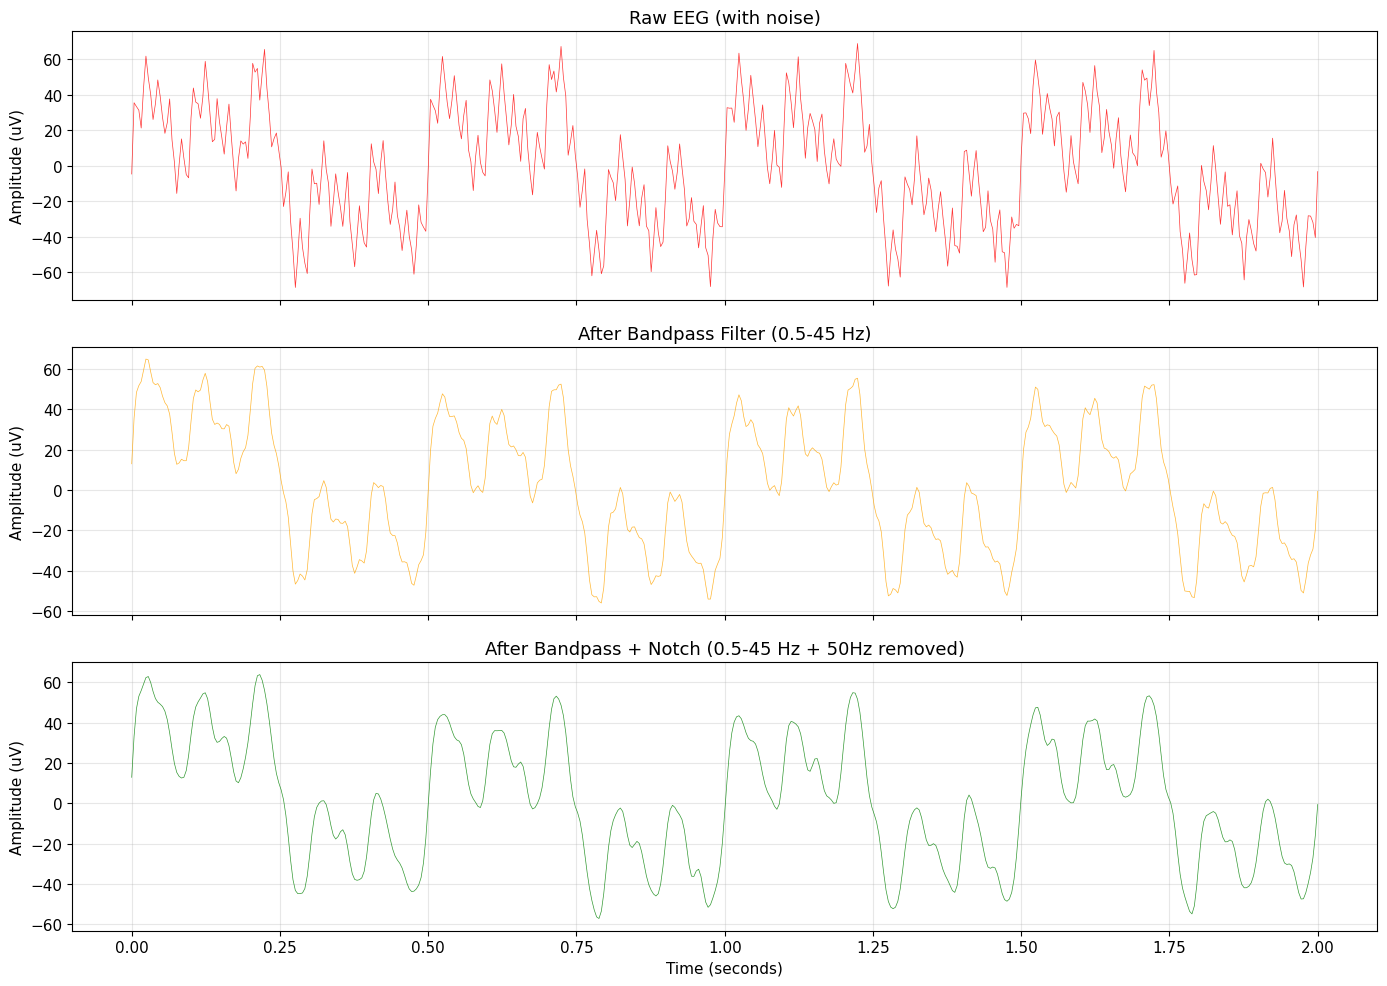

In [22]:
# 时域对比：原始 vs 滤波后
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 显示前 2 秒数据
t_limit = 2.0
mask = times <= t_limit

axes[0].plot(times[mask], eeg_noisy[mask], color='red', linewidth=0.5, alpha=0.8)
axes[0].set_title('Raw EEG (with noise)', fontsize=13)
axes[0].set_ylabel('Amplitude (uV)', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(times[mask], eeg_bandpassed[mask], color='orange', linewidth=0.5, alpha=0.8)
axes[1].set_title('After Bandpass Filter (0.5-45 Hz)', fontsize=13)
axes[1].set_ylabel('Amplitude (uV)', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(times[mask], eeg_filtered[mask], color='green', linewidth=0.5, alpha=0.8)
axes[2].set_title('After Bandpass + Notch (0.5-45 Hz + 50Hz removed)', fontsize=13)
axes[2].set_ylabel('Amplitude (uV)', fontsize=11)
axes[2].set_xlabel('Time (seconds)', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 频域对比（FFT 功率谱）

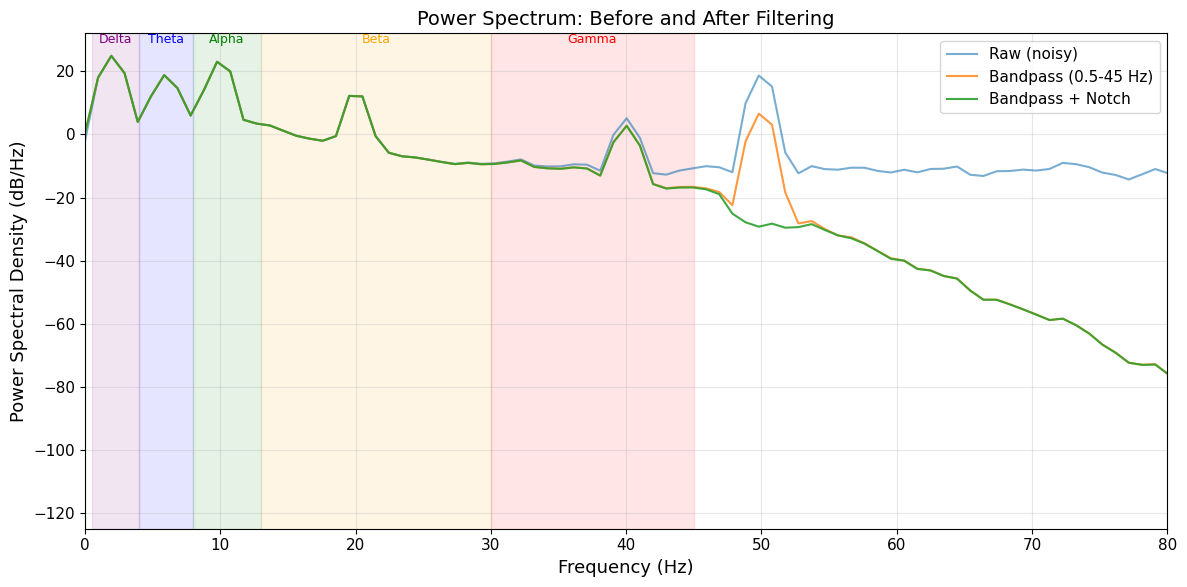

In [23]:
def compute_power_spectrum(data: np.ndarray, fs: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    使用 Welch 方法计算功率谱密度（PSD）
    
    Welch 方法的优势：
    - 将信号分段并加窗，减少频谱泄漏
    - 对重叠段的周期图取平均，降低方差
    - 比简单 FFT 提供更平滑可靠的功率估计
    
    Args:
        data: 输入信号
        fs: 采样频率
    
    Returns:
        frequencies: 频率轴
        psd: 功率谱密度 (uV^2/Hz)
    """
    # nperseg: 每段长度，越长频率分辨率越高，但方差越大
    # noverlap: 段间重叠，通常为 nperseg 的一半
    # Hann 窗会让每段的两端变小，中间权重大。如果完全不重叠，每段边缘的信息会被削弱得比较多。
    # 重叠可以让被上一段窗函数压低的地方，在下一段里可能落到更靠中间的位置，从而提高估计稳定性。
    # SciPy 文档也提到，对于默认 Hann 窗，50% overlap 通常是一个合理折中,
    # 如果 noverlap=0，Welch 就等价于 Bartlett 方法。
    frequencies, psd = signal.welch(
        data,
        fs=fs,
        nperseg=min(256, len(data)),  # 段长度
        noverlap=128,                 # 重叠量
        window='hann',               # 汉宁窗，减少频谱泄漏
        scaling='density'            # 功率谱密度
    )
    return frequencies, psd


# 计算三种信号的功率谱
freqs_noisy, psd_noisy = compute_power_spectrum(eeg_noisy, fs=250)
freqs_bp, psd_bp = compute_power_spectrum(eeg_bandpassed, fs=250)
freqs_filt, psd_filt = compute_power_spectrum(eeg_filtered, fs=250)

# 绘制功率谱对比
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(freqs_noisy, 10 * np.log10(psd_noisy), label='Raw (noisy)', alpha=0.6, linewidth=1.5)
ax.plot(freqs_bp, 10 * np.log10(psd_bp), label='Bandpass (0.5-45 Hz)', alpha=0.8, linewidth=1.5)
ax.plot(freqs_filt, 10 * np.log10(psd_filt), label='Bandpass + Notch', alpha=0.9, linewidth=1.5)

ax.set_xlabel('Frequency (Hz)', fontsize=13)
ax.set_ylabel('Power Spectral Density (dB/Hz)', fontsize=13)
ax.set_title('Power Spectrum: Before and After Filtering', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 80)

# 标注典型脑波频段
bands = [('Delta', 0.5, 4, 'purple'), ('Theta', 4, 8, 'blue'), 
         ('Alpha', 8, 13, 'green'), ('Beta', 13, 30, 'orange'), ('Gamma', 30, 45, 'red')]
for name, lo, hi, color in bands:
    ax.axvspan(lo, hi, alpha=0.1, color=color)
    ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.9, name, 
            ha='center', fontsize=9, color=color)

plt.tight_layout()
plt.show()

## 7. 提取特定频段信号

In [24]:
def extract_frequency_band(
    data: np.ndarray,
    fs: float,
    band: Tuple[float, float],
    order: int = 4
) -> np.ndarray:
    """
    提取特定频段的信号成分
    
    Args:
        data: 输入信号
        fs: 采样频率
        band: (low_freq, high_freq) 元组
        order: 滤波器阶数
    
    Returns:
        提取出的频段信号
    """
    low, high = band
    # 确保频率在有效范围内
    low = max(low, 0.1)
    high = min(high, fs / 2 - 1)
    
    # 带通滤波器，提取指定频段的信号成分
    sos = design_bandpass_filter(low, high, fs, order)
    return apply_filter(sos, data, forward_backward=True)


# 定义标准频段
EEG_BANDS = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 45)
}

# 提取各频段信号
band_signals: Dict[str, np.ndarray] = {}
for band_name, (low, high) in EEG_BANDS.items():
    # 提取频段信号
    band_signals[band_name] = extract_frequency_band(eeg_filtered, 250, (low, high))
    print(f"Extracted {band_name} band ({low}-{high} Hz)")

Extracted Delta band (0.5-4 Hz)
Extracted Theta band (4-8 Hz)
Extracted Alpha band (8-13 Hz)
Extracted Beta band (13-30 Hz)
Extracted Gamma band (30-45 Hz)


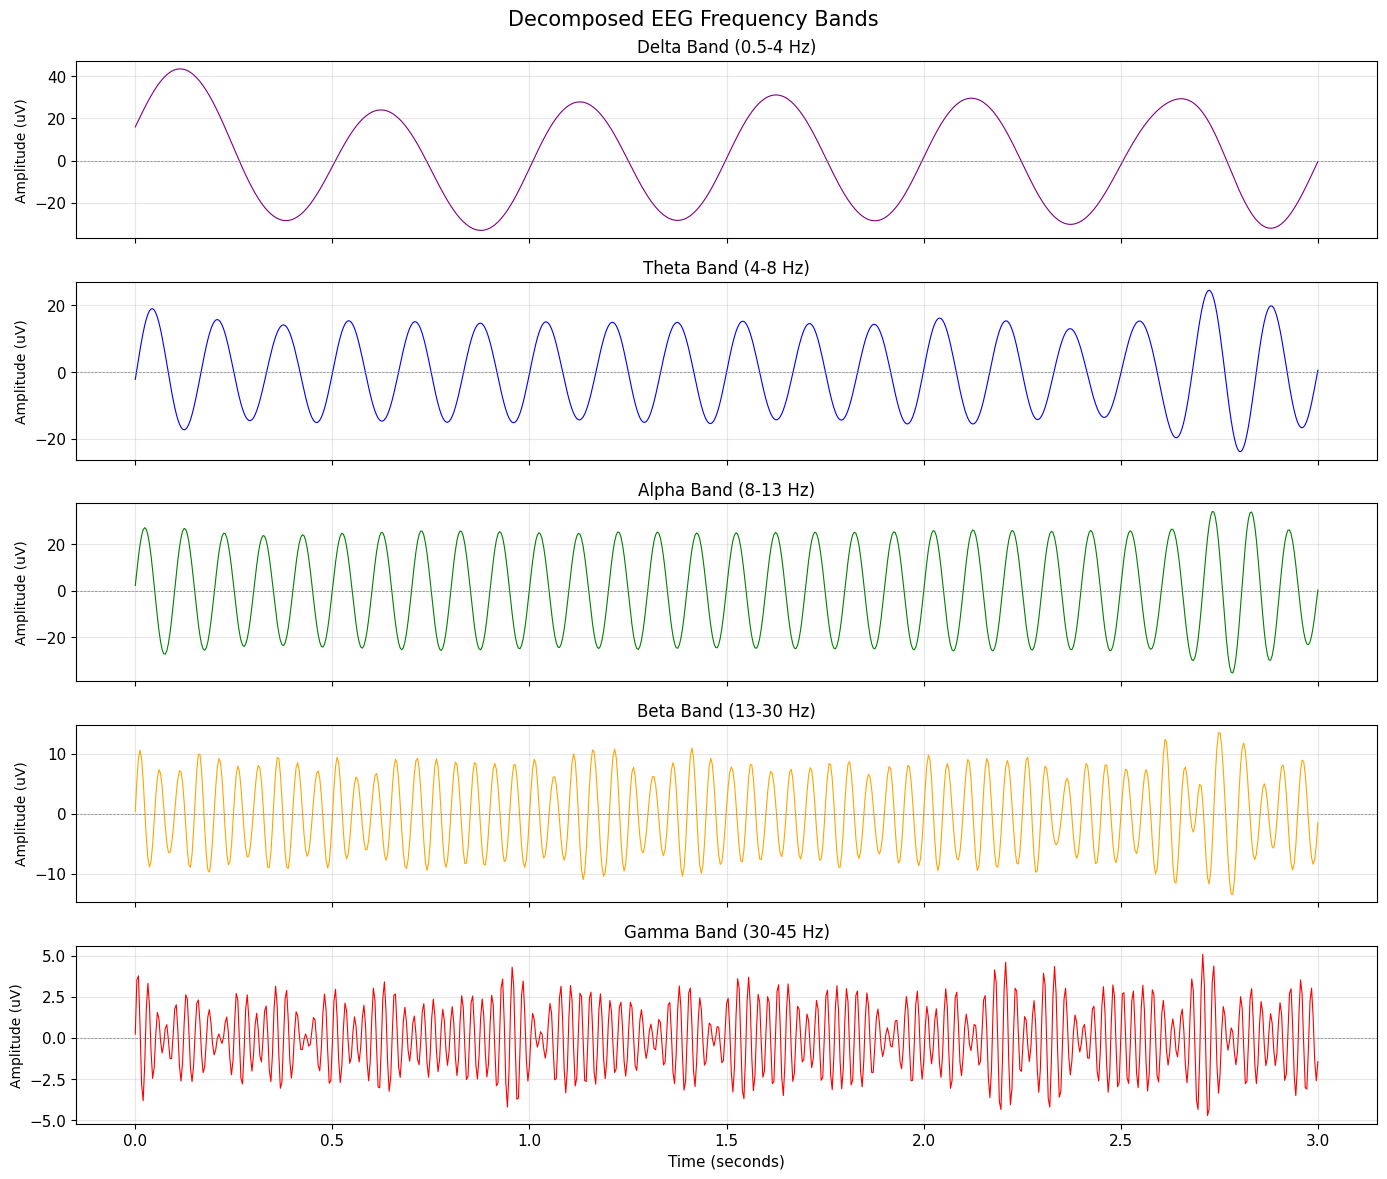

In [25]:
# 可视化各频段信号
fig, axes = plt.subplots(len(EEG_BANDS), 1, figsize=(14, 12), sharex=True)
fig.suptitle('Decomposed EEG Frequency Bands', fontsize=15)

colors = ['purple', 'blue', 'green', 'orange', 'red']
t_limit = 3.0
mask = times <= t_limit

for idx, (band_name, sig) in enumerate(band_signals.items()):
    axes[idx].plot(times[mask], sig[mask], color=colors[idx], linewidth=0.8)
    low, high = EEG_BANDS[band_name]
    axes[idx].set_title(f'{band_name} Band ({low}-{high} Hz)', fontsize=12)
    axes[idx].set_ylabel('Amplitude (uV)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()

## 8. 完整信号处理流水线

In [32]:
class EEGPreprocessor:
    """
    EEG 信号预处理流水线
    
    处理步骤:
        1. 基线校正（去直流/去均值）
        2. 带通滤波
        3. 陷波滤波（可选）
        4. 频段分离
    """
    
    def __init__(
        self,
        sfreq: float = 250.0,
        bandpass_range: Tuple[float, float] = (0.5, 45.0),
        notch_freq: Optional[float] = 50.0,
        filter_order: int = 4
    ):
        """
        Args:
            sfreq: 采样频率（Hz）
            bandpass_range: 带通滤波范围
            notch_freq: 陷波频率，None 表示不应用
            filter_order: 滤波器阶数
        """
        self.sfreq = sfreq
        self.bandpass_range = bandpass_range
        self.notch_freq = notch_freq
        self.filter_order = filter_order
        
        # 预构建滤波器
        self.bandpass_sos = design_bandpass_filter(
            bandpass_range[0], bandpass_range[1], sfreq, filter_order
        )
        
        if notch_freq is not None:
            self.notch_b, self.notch_a = design_notch_filter(notch_freq, sfreq)
    
    def preprocess(self, data: np.ndarray) -> np.ndarray:
        """
        对多通道 EEG 数据进行完整预处理
        
        Args:
            data: 形状为 (n_channels, n_samples) 或 (n_samples,) 的数组
        
        Returns:
            预处理后的数据
        """
        # 确保 2D 格式
        if data.ndim == 1:
            data = data[np.newaxis, :]
        
        # data shape(n_channels, n_samples)
        
        processed = np.copy(data)
        
        # 步骤 1: 基线校正（减去均值，去除直流偏移）
        processed = processed - np.mean(processed, axis=1, keepdims=True)
        
        # 步骤 2: 带通滤波：对每个通道应用带通滤波器
        for i in range(processed.shape[0]):
            processed[i] = apply_filter(self.bandpass_sos, processed[i])
        
        # 步骤 3: 陷波滤波：对每个通道应用陷波滤波器
        if self.notch_freq is not None:
            for i in range(processed.shape[0]):
                processed[i] = signal.filtfilt(self.notch_b, self.notch_a, processed[i])
        
        return processed
    
    def extract_all_bands(self, data: np.ndarray) -> Dict[str, np.ndarray]:
        """
        提取所有标准 EEG 频段
        
        Args:
            data: 已预处理的信号
        
        Returns:
            字典，键为频段名，值为提取的信号
        """
        if data.ndim == 1:
            data = data[np.newaxis, :]
        
        band_data = {}
        for band_name, (low, high) in EEG_BANDS.items():
            sos = design_bandpass_filter(low, high, self.sfreq, self.filter_order)
            band_result = np.zeros_like(data)
            # 对每个通道应用频段滤波器
            for i in range(data.shape[0]):
                band_result[i] = apply_filter(sos, data[i])
            band_data[band_name] = band_result
            # band_data[band_name] shape(n_channels, n_samples)
        
        return band_data


# 使用示例
preprocessor = EEGPreprocessor(
    sfreq=250.0,
    bandpass_range=(0.5, 45.0),
    notch_freq=50.0,
    filter_order=4
)

# 模拟 8 通道数据
# eeg_noisy + 一段随机噪声
multi_channel_data = np.array(
    [
        eeg_noisy 
        + np.random.randn(len(eeg_noisy)) * 2 
        for _ in range(8)
    ]
)
print(f"Input data shape: {multi_channel_data.shape}")

# 执行预处理
clean_data = preprocessor.preprocess(multi_channel_data)
print(f"Processed data shape: {clean_data.shape}")

# 提取第0通道的频段
band_decomposition = preprocessor.extract_all_bands(clean_data[0])
print(f"\nExtracted bands: {list(band_decomposition.keys())}")
for key, value in band_decomposition.items():
    print(f"{key} data shape: {value.shape}")

Input data shape: (8, 2500)
Processed data shape: (8, 2500)

Extracted bands: ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
Delta data shape: (1, 2500)
Theta data shape: (1, 2500)
Alpha data shape: (1, 2500)
Beta data shape: (1, 2500)
Gamma data shape: (1, 2500)


## 9. 知识点总结

### 滤波器设计关键参数
- **滤波器类型**：Butterworth（最大平坦）是 EEG 处理的首选
- **阶数选择**：4 阶通常平衡了陡峭度和数值稳定性
- **零相位滤波**：`filtfilt` 消除相位延迟，适用于离线处理
- **SOS 格式**：二阶节格式比直接 b,a 系数数值稳定性更好

### 典型 EEG 预处理流水线
```
原始信号 -> 基线校正 -> 带通滤波(0.5-45Hz) -> 陷波滤波(50/60Hz) -> 干净信号
```

### 注意事项
1. 滤波会引入**边界效应**，信号首尾部分可能失真
2. 实时应用中不能使用 `filtfilt`（需要未来数据），应使用 `sosfilt`
3. 过高的滤波器阶数可能导致数值不稳定
4. 陷波滤波器的 Q 值过高会引入振铃效应

## 10. 练习任务

1. 实现一个高通滤波器（截止频率 1 Hz），比较与带通滤波器的效果差异
2. 尝试不同的滤波器阶数（2, 4, 8），观察频率响应的变化
3. 实现一个基于 FIR 滤波器的方案，对比 IIR 与 FIR 的性能差异
4. 编写函数自动检测信号中的工频干扰强度

---
*参考资料: [SciPy Signal Processing](https://docs.scipy.org/doc/scipy/reference/signal.html)*